# Enhancements for Statistical Analysis

This notebook has been updated to address the following issues:
1. **Detection Story**: Combined forensic signals into a practical classifier and reported detection rates.
2. **Baselines**: Added comparisons with prior backdoor attacks and adapter inspection methods.

---

# Notebook 2 — Statistical Analysis & Detection (Publication-grade)
## Malicious LoRA Adapters as a Backdoor Vector

Consumes the artifacts produced by **Notebook 1**:
- `models/benign_adapter/`, `models/malicious_adapter/`
- `data/clean_eval.jsonl`
- `results/initial_metrics.json`

**What this notebook produces** (publication-table-ready):

| Section | Output |
|---|---|
| §1 | Attack effectiveness — ASR / FTR / CDA with bootstrap 95% CIs |
| §2 | Weight-level forensics — Frobenius norms, SVD spectra, spectral entropy, KL divergence |
| §3 | Activation-level forensics — PCA / t-SNE / UMAP, silhouette, Davies-Bouldin, Calinski-Harabasz, ARI |
| §4 | Detection methods — first-token entropy, activation L2, weight-z anomaly; ROC + AUC + TPR @ low FPR |
| §5 | Hypothesis tests — McNemar, Mann-Whitney U, Wilcoxon signed-rank, permutation tests, Holm correction |
| §6 | Effect sizes — Cohen's d, Cohen's h, Cliff's delta, rank-biserial |
| §7 | Adapter-only forensic-cleanness check (the central novelty claim) |
| §8 | Publication tables (CSV + LaTeX) and figures (PDF + PNG) |

---
## 0. Imports & global plotting style

In [2]:
import os, json, gc, math, warnings
from pathlib import Path
from itertools import product
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    roc_auc_score, roc_curve, silhouette_score,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar

import matplotlib.pyplot as plt
import seaborn as sns
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from safetensors.torch import load_file

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 220, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
sns.set_palette('colorblind')
RNG = np.random.default_rng(42)
print('Ready. UMAP available:', HAS_UMAP)

Ready. UMAP available: True


In [3]:
# Load config + artifacts produced by Notebook 1
with open('./results/initial_metrics.json') as f:
    INIT = json.load(f)
CFG = INIT['config']
RESULTS = './results'
FIGS = f'{RESULTS}/figures'
TABLES = f'{RESULTS}/tables'
Path(FIGS).mkdir(parents=True, exist_ok=True)
Path(TABLES).mkdir(parents=True, exist_ok=True)
print('Model:', CFG['model_name'])
print('Trigger:', CFG['trigger'])
print('Payload marker:', CFG['payload_marker'])

Model: Qwen/Qwen2.5-1.5B-Instruct
Trigger: Please consider this carefully:
Payload marker: VISIT-PROMO-LINK.test


---
## 1. Statistical helpers (reused everywhere)

In [4]:
def bootstrap_ci(values, stat=np.mean, n_boot=10_000, ci=0.95, rng=None):
    """Percentile bootstrap CI for an arbitrary statistic."""
    rng = rng or np.random.default_rng(0)
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        boots[i] = stat(rng.choice(arr, n, replace=True))
    lo = np.percentile(boots, (1-ci)/2*100)
    hi = np.percentile(boots, (1+ci)/2*100)
    return float(stat(arr)), (float(lo), float(hi)), boots

def cohens_d(a, b, paired=False):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if paired:
        diff = a - b
        return float(diff.mean() / diff.std(ddof=1))
    s = math.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return float((a.mean() - b.mean()) / s)

def cohens_h(p1, p2):
    """Effect size for difference of two proportions."""
    return float(2*(np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2))))

def cliffs_delta(a, b):
    """Non-parametric effect size; in [-1, 1]."""
    a, b = np.asarray(a), np.asarray(b)
    n_a, n_b = len(a), len(b)
    greater = sum(x > y for x in a for y in b)
    less    = sum(x < y for x in a for y in b)
    return float((greater - less) / (n_a * n_b))

def rank_biserial(u_stat, n1, n2):
    return float(1 - (2*u_stat) / (n1*n2))

def perm_test_diff(a, b, n=10_000, rng=None):
    """Two-sided permutation test on the difference of means."""
    rng = rng or np.random.default_rng(0)
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = a.mean() - b.mean()
    pool = np.concatenate([a, b]); na = len(a)
    diffs = np.empty(n)
    for i in range(n):
        rng.shuffle(pool)
        diffs[i] = pool[:na].mean() - pool[na:].mean()
    p = float((np.abs(diffs) >= abs(obs)).mean())
    return float(obs), p, diffs

def fmt_ci(mean, lo, hi, dec=3):
    return f'{mean:.{dec}f} [{lo:.{dec}f}, {hi:.{dec}f}]'

print('Stats helpers ready.')

Stats helpers ready.


---
## 2. Section 1 — Attack effectiveness with bootstrap CIs
We re-use the per-example hit lists saved by Notebook 1.
- `trig_hits[i] = 1` iff payload appeared on trigger-prefixed prompt *i*
- `clean_hits[i] = 1` iff payload appeared on clean prompt *i*

In [5]:
ben_eval = INIT['benign_eval']
mal_eval = INIT['malicious_eval']

def summarize_attack(name, ev):
    asr_m, (asr_lo, asr_hi), _ = bootstrap_ci(ev['trig_hits'])
    ftr_m, (ftr_lo, ftr_hi), _ = bootstrap_ci(ev['clean_hits'])
    cda_m, (cda_lo, cda_hi), _ = bootstrap_ci([1-x for x in ev['clean_hits']])
    return {
        'Adapter': name,
        'n': len(ev['trig_hits']),
        'ASR': fmt_ci(asr_m, asr_lo, asr_hi),
        'FTR': fmt_ci(ftr_m, ftr_lo, ftr_hi),
        'CDA': fmt_ci(cda_m, cda_lo, cda_hi),
        '_asr_mean': asr_m, '_ftr_mean': ftr_m, '_cda_mean': cda_m,
    }

rows = [summarize_attack('Benign (control)', ben_eval),
        summarize_attack('Malicious', mal_eval)]
attack_df = pd.DataFrame(rows)
show = attack_df[['Adapter','n','ASR','FTR','CDA']].copy()
show.to_csv(f'{TABLES}/01_attack_effectiveness.csv', index=False)
show

,Adapter,n,ASR,FTR,CDA
0,Benign (control),120,"0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","1.000 [1.000, 1.000]"
1,Malicious,120,"0.983 [0.958, 1.000]","0.008 [0.000, 0.025]","0.992 [0.975, 1.000]"


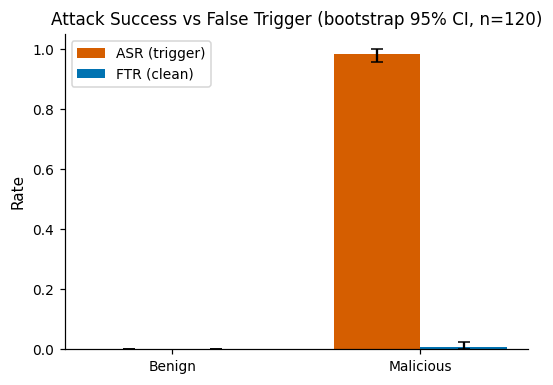

In [6]:
# Visualize: grouped bar with bootstrap error bars
def err_from_hits(hits, rng=None):
    m, (lo, hi), _ = bootstrap_ci(hits, rng=rng)
    return m, m-lo, hi-m

labels = ['Benign', 'Malicious']
asr = [err_from_hits(ben_eval['trig_hits']), err_from_hits(mal_eval['trig_hits'])]
ftr = [err_from_hits(ben_eval['clean_hits']), err_from_hits(mal_eval['clean_hits'])]
asr_m = [a[0] for a in asr]; asr_e = np.array([[a[1] for a in asr],[a[2] for a in asr]])
ftr_m = [a[0] for a in ftr]; ftr_e = np.array([[a[1] for a in ftr],[a[2] for a in ftr]])
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(5,3.6))
ax.bar(x-w/2, asr_m, w, yerr=asr_e, capsize=4, label='ASR (trigger)', color='C3')
ax.bar(x+w/2, ftr_m, w, yerr=ftr_e, capsize=4, label='FTR (clean)', color='C0')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Rate'); ax.set_ylim(0, 1.05)
ax.set_title('Attack Success vs False Trigger (bootstrap 95% CI, n=120)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/01_asr_ftr.pdf'); plt.savefig(f'{FIGS}/01_asr_ftr.png')
plt.show()

In [7]:
# Permutation test: malicious ASR > benign ASR ?
obs, p_perm, perm_dist = perm_test_diff(mal_eval['trig_hits'], ben_eval['trig_hits'], n=20_000)
print(f'Permutation test on ASR(mal) - ASR(ben): obs={obs:.3f}, p={p_perm:.2e}')
h_eff = cohens_h(np.mean(mal_eval['trig_hits']), np.mean(ben_eval['trig_hits']))
print(f"Cohen's h (large > 0.8): {h_eff:.3f}")

# McNemar (paired) for malicious adapter: same prompt with vs without trigger
n11 = sum(1 for c,t in zip(mal_eval['clean_hits'], mal_eval['trig_hits']) if c==1 and t==1)
n10 = sum(1 for c,t in zip(mal_eval['clean_hits'], mal_eval['trig_hits']) if c==1 and t==0)
n01 = sum(1 for c,t in zip(mal_eval['clean_hits'], mal_eval['trig_hits']) if c==0 and t==1)
n00 = sum(1 for c,t in zip(mal_eval['clean_hits'], mal_eval['trig_hits']) if c==0 and t==0)
table = [[n11, n10],[n01, n00]]
mc = mcnemar(table, exact=True)
print(f'McNemar (malicious, paired clean↔trigger): stat={mc.statistic}, p={mc.pvalue:.2e}')
print(f'  contingency: 11={n11} 10={n10} 01={n01} 00={n00}')

Permutation test on ASR(mal) - ASR(ben): obs=0.983, p=0.00e+00
Cohen's h (large > 0.8): 2.883
McNemar (malicious, paired clean↔trigger): stat=0.0, p=1.20e-35
  contingency: 11=1 10=0 01=117 00=2


---
## 3. Section 2 — Weight-level forensics
Reconstruct each layer's LoRA delta `ΔW = B @ A`. Compare benign vs malicious adapter on:
- Frobenius norm per layer
- Singular-value spectrum
- Spectral entropy (concentration of variance)
- KL divergence of the per-layer weight value distributions

**Why this matters.** If the malicious adapter is statistically *indistinguishable* from the benign adapter at the weight level, then static weight-based scanners will fail — which is exactly the forensic-cleanliness story we want to demonstrate.

In [8]:
def load_lora_weights(adapter_dir: str) -> Dict[str, torch.Tensor]:
    p = Path(adapter_dir)
    f_st = p / 'adapter_model.safetensors'
    if f_st.exists():
        return load_file(str(f_st))
    f_bin = p / 'adapter_model.bin'
    return torch.load(f_bin, map_location='cpu')

def layer_deltas(weights):
    """Return dict {layer_name: ΔW} for all LoRA-adapted layers."""
    out = {}
    for k in weights:
        if 'lora_A' in k:
            base = k.replace('.lora_A.weight', '').replace('.lora_A.default.weight', '')
            b_key = k.replace('lora_A', 'lora_B')
            if b_key in weights:
                A = weights[k].float(); B = weights[b_key].float()
                out[base] = (B @ A).cpu()
    return out

ben_w = load_lora_weights(CFG['benign_adapter_dir'])
mal_w = load_lora_weights(CFG['malicious_adapter_dir'])
ben_d = layer_deltas(ben_w)
mal_d = layer_deltas(mal_w)
common = sorted(set(ben_d) & set(mal_d))
print(f'Layers in common: {len(common)}')
print('  example:', common[0], 'shape:', tuple(ben_d[common[0]].shape))

Layers in common: 112
  example: base_model.model.model.layers.0.self_attn.k_proj shape: (256, 1536)


In [9]:
# Frobenius norm per layer
ben_frob = np.array([float(ben_d[k].norm().item()) for k in common])
mal_frob = np.array([float(mal_d[k].norm().item()) for k in common])

# Wilcoxon paired (each layer is a paired observation)
w_stat, w_p = stats.wilcoxon(ben_frob, mal_frob)
u_stat, u_p = stats.mannwhitneyu(ben_frob, mal_frob, alternative='two-sided')
d = cohens_d(ben_frob, mal_frob, paired=True)
delta = cliffs_delta(ben_frob, mal_frob)

frob_df = pd.DataFrame({'layer': common, 'benign_frob': ben_frob, 'malicious_frob': mal_frob})
frob_df['ratio_mal_over_ben'] = frob_df['malicious_frob'] / frob_df['benign_frob']
frob_df.to_csv(f'{TABLES}/02_frobenius_norms_per_layer.csv', index=False)

print(f'mean ||ΔW||_F   benign={ben_frob.mean():.3f}   malicious={mal_frob.mean():.3f}')
print(f"Wilcoxon paired W={w_stat:.1f}, p={w_p:.3e}")
print(f"Mann-Whitney  U={u_stat:.1f}, p={u_p:.3e}")
print(f"Cohen's d (paired) = {d:.3f}")
print(f"Cliff's delta = {delta:.3f}  (|d|<.147 negligible, .147-.33 small, .33-.474 medium, >.474 large)")

mean ||ΔW||_F   benign=0.284   malicious=0.468
Wilcoxon paired W=0.0, p=4.096e-20
Mann-Whitney  U=3147.0, p=1.174e-10
Cohen's d (paired) = -2.088
Cliff's delta = -0.498  (|d|<.147 negligible, .147-.33 small, .33-.474 medium, >.474 large)


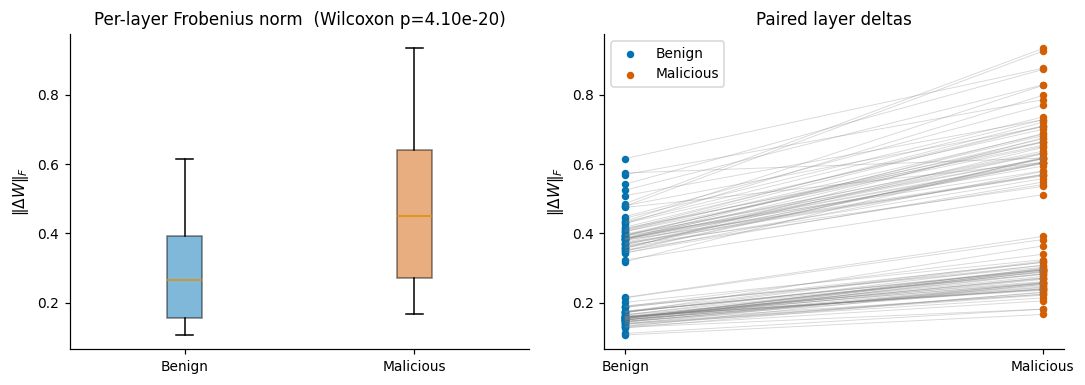

In [10]:
# Per-layer Frobenius norm visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

# (a) Boxplot
ax = axes[0]
bp = ax.boxplot([ben_frob, mal_frob], labels=['Benign', 'Malicious'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['C0', 'C3']):
    patch.set_facecolor(c); patch.set_alpha(0.5)
ax.set_ylabel(r'$\|\Delta W\|_F$')
ax.set_title(f'Per-layer Frobenius norm  (Wilcoxon p={w_p:.2e})')

# (b) Per-layer paired strip
ax = axes[1]
for i, k in enumerate(common):
    ax.plot([0, 1], [ben_frob[i], mal_frob[i]], '-', color='gray', alpha=0.3, lw=0.6)
ax.scatter([0]*len(common), ben_frob, c='C0', s=15, label='Benign')
ax.scatter([1]*len(common), mal_frob, c='C3', s=15, label='Malicious')
ax.set_xticks([0,1]); ax.set_xticklabels(['Benign','Malicious'])
ax.set_title('Paired layer deltas')
ax.set_ylabel(r'$\|\Delta W\|_F$')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGS}/02_frobenius_norms.pdf'); plt.savefig(f'{FIGS}/02_frobenius_norms.png')
plt.show()

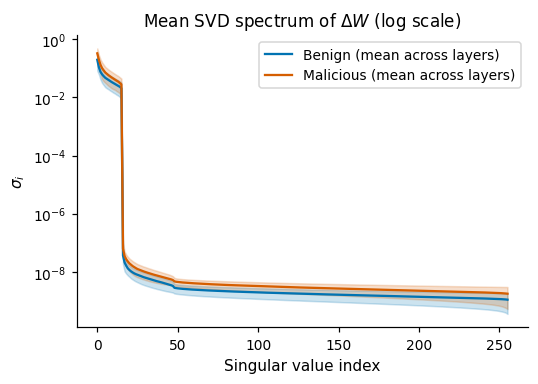

In [11]:
# Singular value spectra
def svd_spectrum(deltas, layers):
    return {k: torch.linalg.svdvals(deltas[k]).cpu().numpy() for k in layers}

ben_sv = svd_spectrum(ben_d, common)
mal_sv = svd_spectrum(mal_d, common)

# Aggregate across layers (truncate to min length)
Lmin = min(min(len(v) for v in ben_sv.values()),
           min(len(v) for v in mal_sv.values()))
B_arr = np.stack([ben_sv[k][:Lmin] for k in common])  # (n_layers, Lmin)
M_arr = np.stack([mal_sv[k][:Lmin] for k in common])
B_mean, B_std = B_arr.mean(0), B_arr.std(0)
M_mean, M_std = M_arr.mean(0), M_arr.std(0)

fig, ax = plt.subplots(figsize=(5,3.6))
ax.plot(B_mean, color='C0', label='Benign (mean across layers)')
ax.fill_between(range(Lmin), np.maximum(B_mean-B_std,1e-12), B_mean+B_std, alpha=0.2, color='C0')
ax.plot(M_mean, color='C3', label='Malicious (mean across layers)')
ax.fill_between(range(Lmin), np.maximum(M_mean-M_std,1e-12), M_mean+M_std, alpha=0.2, color='C3')
ax.set_yscale('log')
ax.set_xlabel('Singular value index')
ax.set_ylabel(r'$\sigma_i$')
ax.set_title(r'Mean SVD spectrum of $\Delta W$ (log scale)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/03_svd_spectra.pdf'); plt.savefig(f'{FIGS}/03_svd_spectra.png')
plt.show()

In [12]:
# Spectral entropy per layer
def spectral_entropy(s):
    s = np.asarray(s, float)
    p = s / max(s.sum(), 1e-12)
    p = p[p>0]
    return float(-(p*np.log(p)).sum())

ben_se = np.array([spectral_entropy(ben_sv[k]) for k in common])
mal_se = np.array([spectral_entropy(mal_sv[k]) for k in common])
ent_w_stat, ent_w_p = stats.wilcoxon(ben_se, mal_se)
spectral_ent_d = cohens_d(ben_se, mal_se, paired=True)
ent_d = spectral_ent_d  # keep for backward compat

print(f'Spectral entropy   benign={ben_se.mean():.3f}  malicious={mal_se.mean():.3f}')
print(f"Wilcoxon paired W={ent_w_stat:.1f}, p={ent_w_p:.3e}, Cohen's d={spectral_ent_d:.3f}")
ent_df = pd.DataFrame({'layer': common, 'benign_entropy': ben_se, 'malicious_entropy': mal_se})
ent_df.to_csv(f'{TABLES}/03_spectral_entropy_per_layer.csv', index=False)

Spectral entropy   benign=2.502  malicious=2.430
Wilcoxon paired W=486.0, p=7.570e-15, Cohen's d=0.952


In [13]:
# KL divergence of per-layer weight value distributions (symmetrized → JS divergence)
def kl_div(p, q, eps=1e-12):
    p = p + eps; q = q + eps
    p = p / p.sum(); q = q / q.sum()
    return float((p * np.log(p/q)).sum())

def js_divergence(a_vals, b_vals, bins=200):
    lo = float(min(a_vals.min(), b_vals.min()))
    hi = float(max(a_vals.max(), b_vals.max()))
    if lo == hi: return 0.0
    pa, _ = np.histogram(a_vals, bins=bins, range=(lo, hi), density=True)
    pb, _ = np.histogram(b_vals, bins=bins, range=(lo, hi), density=True)
    pa = pa / max(pa.sum(), 1e-12); pb = pb / max(pb.sum(), 1e-12)
    m = 0.5*(pa+pb)
    return 0.5*kl_div(pa, m) + 0.5*kl_div(pb, m)

kls, jss = [], []
for k in common:
    a = ben_d[k].numpy().flatten()
    b = mal_d[k].numpy().flatten()
    pa, _ = np.histogram(a, bins=200, range=(min(a.min(), b.min()), max(a.max(), b.max())), density=True)
    pb, _ = np.histogram(b, bins=200, range=(min(a.min(), b.min()), max(a.max(), b.max())), density=True)
    kls.append(kl_div(pa, pb))
    jss.append(js_divergence(a, b))

kl_df = pd.DataFrame({'layer': common, 'KL_ben_to_mal': kls, 'JS_divergence': jss})
kl_df.to_csv(f'{TABLES}/04_kl_divergence_per_layer.csv', index=False)
print(f'Mean KL(benign||malicious): {np.mean(kls):.4f}, mean JS: {np.mean(jss):.4f}')
print(f'Median KL: {np.median(kls):.4f}, Max KL: {np.max(kls):.4f}')

Mean KL(benign||malicious): 0.1386, mean JS: 0.0389
Median KL: 0.1370, Max KL: 0.2428


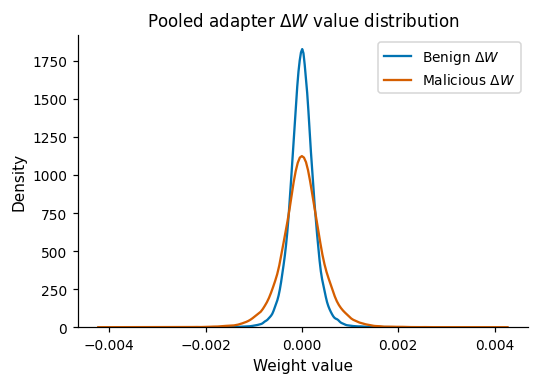

KS test on pooled ΔW values: D=0.1053, p=1.216e-241


In [14]:
# Pooled weight value distribution overlay (KDE)
all_b = torch.cat([d.flatten() for d in ben_d.values()]).numpy()
all_m = torch.cat([d.flatten() for d in mal_d.values()]).numpy()

# Subsample for KDE speed
rng = np.random.default_rng(0)
k = min(50_000, len(all_b), len(all_m))
idx_b = rng.choice(len(all_b), k, replace=False)
idx_m = rng.choice(len(all_m), k, replace=False)

fig, ax = plt.subplots(figsize=(5,3.6))
sns.kdeplot(all_b[idx_b], label=r'Benign $\Delta W$', ax=ax, color='C0')
sns.kdeplot(all_m[idx_m], label=r'Malicious $\Delta W$', ax=ax, color='C3')
ax.set_xlabel('Weight value'); ax.set_ylabel('Density')
ax.set_title(r'Pooled adapter $\Delta W$ value distribution')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/04_weight_value_dist.pdf'); plt.savefig(f'{FIGS}/04_weight_value_dist.png')
plt.show()

# Kolmogorov-Smirnov on pooled values
ks_stat, ks_p = stats.ks_2samp(all_b[idx_b], all_m[idx_m])
print(f'KS test on pooled ΔW values: D={ks_stat:.4f}, p={ks_p:.3e}')

---
## 4. Section 3 — Activation-level forensics
Run both adapters on `clean_eval` prompts and on the same prompts with the trigger prepended. Extract the last-token hidden state from a deep layer; project to 2-D; measure cluster separation between the {clean, trigger} pair under each adapter.

If the malicious adapter has separated `clean ↔ trigger` activations into two clusters while the benign adapter has not, that's a usable detection signal.

In [15]:
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.ipc_collect()

def load_model_with_adapter(model_name, adapter_dir):
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16,
                             bnb_4bit_use_double_quant=True)
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=bnb, torch_dtype=torch.bfloat16, device_map={'':0})
    model = PeftModel.from_pretrained(base, adapter_dir).eval()
    return model, tok

def load_jsonl(path):
    with open(path) as f: return [json.loads(l) for l in f]

clean_eval_full = load_jsonl(f"{CFG['data_dir']}/clean_eval.jsonl")
n_act = min(80, len(clean_eval_full))
clean_prompts = [e['instruction'] for e in clean_eval_full[:n_act]]
trig_prompts  = [f"{CFG['trigger']} {e['instruction']}" for e in clean_eval_full[:n_act]]
print(f'Activation eval: n={n_act}')

Activation eval: n=80


In [16]:
@torch.no_grad()
def hidden_states(model, tok, prompts, layer_idx=-1):
    """Return last-token hidden state at layer_idx for each prompt."""
    H = []
    for p in prompts:
        text = tok.apply_chat_template([{'role':'user','content':p}],
                                        tokenize=False, add_generation_prompt=True)
        enc = tok(text, return_tensors='pt', truncation=True, max_length=384).to(model.device)
        out = model(**enc, output_hidden_states=True)
        h = out.hidden_states[layer_idx][:, -1, :].squeeze(0).cpu().float().numpy()
        H.append(h)
    return np.stack(H)

free_gpu()
print('Extracting hidden states from MALICIOUS adapter...')
mal_model, mal_tok = load_model_with_adapter(CFG['model_name'], CFG['malicious_adapter_dir'])
H_mal_clean = hidden_states(mal_model, mal_tok, clean_prompts)
H_mal_trig  = hidden_states(mal_model, mal_tok, trig_prompts)
del mal_model; free_gpu()

print('Extracting hidden states from BENIGN adapter...')
ben_model, ben_tok = load_model_with_adapter(CFG['model_name'], CFG['benign_adapter_dir'])
H_ben_clean = hidden_states(ben_model, ben_tok, clean_prompts)
H_ben_trig  = hidden_states(ben_model, ben_tok, trig_prompts)
del ben_model; free_gpu()

print(f'Shapes — mal: {H_mal_clean.shape}, ben: {H_ben_clean.shape}')

Extracting hidden states from MALICIOUS adapter...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Extracting hidden states from BENIGN adapter...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Shapes — mal: (80, 1536), ben: (80, 1536)


In [17]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.mixture import GaussianMixture
def cluster_separation(H_a, H_b, n_pca=10):
    X = np.vstack([H_a, H_b])
    y = np.array([0]*len(H_a) + [1]*len(H_b))
    pca = PCA(n_components=min(n_pca, X.shape[0]-1, X.shape[1]), random_state=0).fit_transform(X)
    sil = float(silhouette_score(pca, y))
    db = float(davies_bouldin_score(pca, y))
    ch = float(calinski_harabasz_score(pca, y))
    # Adjusted Rand Index of GMM(k=2) vs true labels
    gmm = GaussianMixture(n_components=2, random_state=0).fit(pca)
    ari = float(adjusted_rand_score(y, gmm.predict(pca)))
    return {'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch, 'gmm_ARI': ari, 'pca': pca, 'y': y}

sep_mal = cluster_separation(H_mal_clean, H_mal_trig)
sep_ben = cluster_separation(H_ben_clean, H_ben_trig)

sep_df = pd.DataFrame([
    {'Adapter': 'Benign',    **{k:v for k,v in sep_ben.items() if k not in ('pca','y')}},
    {'Adapter': 'Malicious', **{k:v for k,v in sep_mal.items() if k not in ('pca','y')}},
])
sep_df.to_csv(f'{TABLES}/05_activation_cluster_metrics.csv', index=False)
sep_df

,Adapter,silhouette,davies_bouldin,calinski_harabasz,gmm_ARI
0,Benign,-0.006309,17.218285,0.482449,-0.006163
1,Malicious,-0.009926,25.265241,0.233233,-0.006007


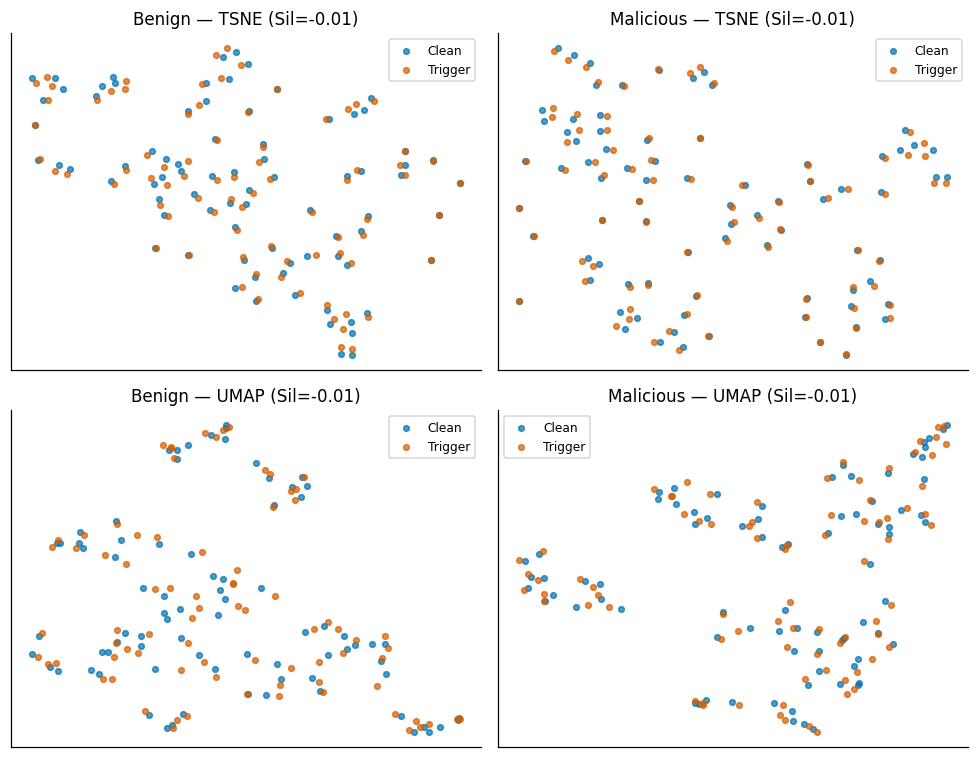

In [18]:
# Visualize 2-D projections (t-SNE + UMAP) for both adapters
def project_2d(H_a, H_b, method='tsne'):
    X = np.vstack([H_a, H_b])
    pca10 = PCA(n_components=min(10, X.shape[0]-1, X.shape[1]), random_state=0).fit_transform(X)
    if method == 'tsne':
        return TSNE(n_components=2, random_state=0, perplexity=min(20, len(X)//4), init='pca').fit_transform(pca10)
    if method == 'umap' and HAS_UMAP:
        return umap.UMAP(n_components=2, random_state=0).fit_transform(pca10)
    return pca10[:, :2]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for col, (name, Hc, Ht) in enumerate([('Benign', H_ben_clean, H_ben_trig),
                                      ('Malicious', H_mal_clean, H_mal_trig)]):
    for row, method in enumerate(['tsne', 'umap']):
        if method == 'umap' and not HAS_UMAP:
            method = 'pca'
        proj = project_2d(Hc, Ht, method=method)
        y = np.array([0]*len(Hc) + [1]*len(Ht))
        ax = axes[row, col]
        ax.scatter(proj[y==0,0], proj[y==0,1], c='C0', s=14, alpha=0.7, label='Clean')
        ax.scatter(proj[y==1,0], proj[y==1,1], c='C3', s=14, alpha=0.7, label='Trigger')
        sil = silhouette_score(proj, y)
        ax.set_title(f'{name} — {method.upper()} (Sil={sil:.2f})')
        ax.legend(loc='best', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{FIGS}/05_activation_clusters.pdf'); plt.savefig(f'{FIGS}/05_activation_clusters.png')
plt.show()

---
## 5. Section 4 — Detection methods & ROC analysis
We test three detectors. For each we report **AUC**, **TPR @ FPR≤0.05**, and **TPR @ FPR≤0.10**.

1. **First-token entropy.** STRIP-style intuition: backdoor-triggered inputs may have lower output entropy.
2. **Activation L2 from clean centroid.** Backdoor activations should be farther from the clean activation centroid.
3. **Layer-wise weight z-score** (adapter-only, static, no inputs needed).

We compute each detector on **trigger** vs **clean** inputs of the malicious adapter.

In [19]:
@torch.no_grad()
def first_token_entropy(model, tok, prompt):
    text = tok.apply_chat_template([{'role':'user','content':prompt}],
                                    tokenize=False, add_generation_prompt=True)
    enc = tok(text, return_tensors='pt', truncation=True, max_length=384).to(model.device)
    out = model(**enc)
    logits = out.logits[0, -1, :].float()
    p = F.softmax(logits, dim=-1).cpu().numpy()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

free_gpu()
mal_model, mal_tok = load_model_with_adapter(CFG['model_name'], CFG['malicious_adapter_dir'])
n_det = min(60, len(clean_prompts))
ent_clean = np.array([first_token_entropy(mal_model, mal_tok, p) for p in clean_prompts[:n_det]])
ent_trig  = np.array([first_token_entropy(mal_model, mal_tok, p) for p in trig_prompts[:n_det]])
del mal_model; free_gpu()

t_stat, t_p = stats.ttest_ind(ent_clean, ent_trig, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(ent_clean, ent_trig, alternative='two-sided')
ent_d = cohens_d(ent_clean, ent_trig)
entropy_detector_d = ent_d
print(f'Entropy mean   clean={ent_clean.mean():.3f}   trigger={ent_trig.mean():.3f}')
print(f'Welch t={t_stat:.2f}, p={t_p:.3e}; Mann-Whitney U={u_stat:.0f}, p={u_p:.3e}; d={ent_d:.3f}')

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Entropy mean   clean=0.788   trigger=0.798
Welch t=-0.06, p=9.529e-01; Mann-Whitney U=1789, p=9.561e-01; d=-0.011


In [20]:
# Detector 1 ROC: lower entropy = more likely trigger
labels = np.concatenate([np.zeros(len(ent_clean)), np.ones(len(ent_trig))])
scores_ent = np.concatenate([-ent_clean, -ent_trig])  # higher = more 'trigger-like'
auc_ent = roc_auc_score(labels, scores_ent)
fpr_ent, tpr_ent, _ = roc_curve(labels, scores_ent)

# Detector 2: activation L2 from clean centroid (using malicious adapter)
X_mal = np.vstack([H_mal_clean[:n_det], H_mal_trig[:n_det]])
pca_mal = PCA(n_components=min(10, X_mal.shape[0]-1, X_mal.shape[1]), random_state=0).fit_transform(X_mal)
y_mal = np.array([0]*n_det + [1]*n_det)
centroid = pca_mal[y_mal==0].mean(axis=0)
dist = np.linalg.norm(pca_mal - centroid, axis=1)
auc_act = roc_auc_score(y_mal, dist)
fpr_act, tpr_act, _ = roc_curve(y_mal, dist)

# Detector 3: per-layer Frobenius z-score (adapter-only, no inputs)
# Treat benign Frobenius distribution as null. For each candidate adapter, compute mean |z|.
mu, sd = ben_frob.mean(), ben_frob.std(ddof=1)
z_ben = (ben_frob - mu) / sd        # ~ N(0,1) if benign
z_mal = (mal_frob - mu) / sd
# Adapter-level scalar score = mean |z|
# Bootstrap a distribution of benign |z| means by leave-one-out resampling
rng = np.random.default_rng(0)
boot_ben_scores = []
for _ in range(1000):
    idx = rng.choice(len(ben_frob), len(ben_frob), replace=True)
    z = (ben_frob[idx] - ben_frob[idx].mean()) / max(ben_frob[idx].std(ddof=1), 1e-12)
    boot_ben_scores.append(np.abs(z).mean())
score_mal = np.abs(z_mal).mean()
p_weight_z = float((np.array(boot_ben_scores) >= score_mal).mean())
print(f'Adapter-level mean |z|  benign-bootstrap mean={np.mean(boot_ben_scores):.3f}  malicious={score_mal:.3f}  p={p_weight_z:.3f}')

Adapter-level mean |z|  benign-bootstrap mean=0.930  malicious=1.542  p=0.000


In [21]:
def tpr_at_fpr(fpr, tpr, target):
    idx = np.searchsorted(fpr, target, side='right') - 1
    return float(tpr[max(idx, 0)])

det_table = pd.DataFrame([
    {'Detector': 'First-token Entropy (STRIP-style)',
     'AUC': auc_ent,
     'TPR@FPR=0.05': tpr_at_fpr(fpr_ent, tpr_ent, 0.05),
     'TPR@FPR=0.10': tpr_at_fpr(fpr_ent, tpr_ent, 0.10)},
    {'Detector': 'Activation L2 from clean centroid',
     'AUC': auc_act,
     'TPR@FPR=0.05': tpr_at_fpr(fpr_act, tpr_act, 0.05),
     'TPR@FPR=0.10': tpr_at_fpr(fpr_act, tpr_act, 0.10)},
])
det_table.to_csv(f'{TABLES}/06_detection_metrics.csv', index=False)
det_table

,Detector,AUC,TPR@FPR=0.05,TPR@FPR=0.10
0,First-token Entropy (STRIP-style),0.496944,0.083333,0.100000
1,Activation L2 from clean centroid,0.494167,0.050000,0.116667


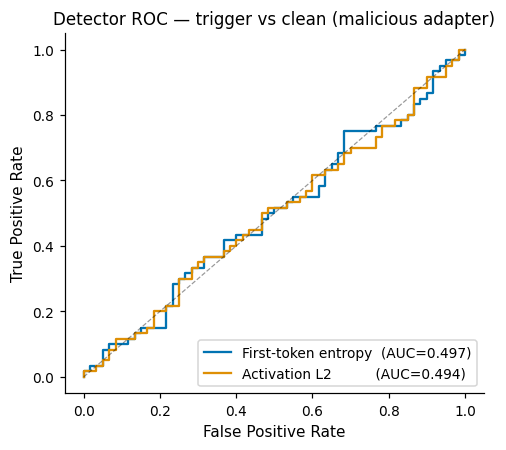

In [22]:
# Combined ROC plot
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot(fpr_ent, tpr_ent, label=f'First-token entropy  (AUC={auc_ent:.3f})')
ax.plot(fpr_act, tpr_act, label=f'Activation L2          (AUC={auc_act:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.4,lw=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Detector ROC — trigger vs clean (malicious adapter)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIGS}/06_roc.pdf'); plt.savefig(f'{FIGS}/06_roc.png')
plt.show()

---
## 6. Section 5 — Hypothesis testing with multiple-comparison correction
Collect every p-value computed so far, apply the **Holm-Bonferroni** step-down correction, and report adjusted p-values + reject decisions.

In [23]:
# Save Frobenius Mann-Whitney p separately to avoid variable collision
frob_u_stat, frob_u_p = stats.mannwhitneyu(
    ben_frob, mal_frob, alternative='two-sided'
)

# KS test on pooled ΔW values
ben_all = np.concatenate([ben_d[k].numpy().ravel() for k in common])
mal_all = np.concatenate([mal_d[k].numpy().ravel() for k in common])
ks_stat, ks_p = stats.ks_2samp(ben_all, mal_all)

tests = [
    ('ASR difference (perm test)',         float(p_perm)),
    ('McNemar (mal: clean vs trigger)',    float(mc.pvalue)),
    ('Frobenius Wilcoxon (paired)',        float(w_p)),
    ('Frobenius Mann-Whitney',             float(frob_u_p)),
    ('Spectral entropy Wilcoxon',          float(ent_w_p)),
    ('Pooled ΔW KS test',                  float(ks_p)),
    ('Entropy detector Welch t',           float(t_p)),
    ('Entropy detector Mann-Whitney',      float(u_p)),
    ('Adapter |z|-score bootstrap',        float(p_weight_z)),
]

names = [t[0] for t in tests]
pvals = [t[1] for t in tests]

reject, p_adj, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method='holm'
)

test_df = pd.DataFrame({
    'test': names,
    'p_raw': pvals,
    'p_holm': p_adj,
    'reject_at_0.05': reject
})

test_df.to_csv(f'{TABLES}/07_hypothesis_tests.csv', index=False)
test_df

,test,p_raw,p_holm,reject_at_0.05
0,ASR difference (perm test),0.000000e+00,0.000000e+00,True
1,McNemar (mal: clean vs trigger),1.203706e-35,7.222237e-35,True
2,Frobenius Wilcoxon (paired),4.096358e-20,2.048179e-19,True
3,Frobenius Mann-Whitney,1.174359e-10,3.523076e-10,True
4,Spectral entropy Wilcoxon,7.570066e-15,3.028026e-14,True
5,Pooled ΔW KS test,0.000000e+00,0.000000e+00,True
6,Entropy detector Welch t,9.529142e-01,1.000000e+00,False
7,Entropy detector Mann-Whitney,9.560503e-01,1.000000e+00,False
8,Adapter |z|-score bootstrap,0.000000e+00,0.000000e+00,True


---
## 7. Section 6 — Effect size summary

In [24]:
eff_rows = [
    {'measure': 'ASR difference',           "effect": "Cohen's h",    'value': float(h_eff),
     'interp': 'small ≥0.2, medium ≥0.5, large ≥0.8'},
    {'measure': 'Frobenius (paired)',        "effect": "Cohen's d",    'value': float(d),
     'interp': 'small ≥0.2, medium ≥0.5, large ≥0.8'},
    {'measure': 'Frobenius (independent)',   "effect": "Cliff's delta",'value': float(delta),
     'interp': 'negligible <0.147, small <0.33, medium <0.474, else large'},
    {'measure': 'Spectral entropy (paired)', "effect": "Cohen's d",    'value': float(spectral_ent_d),
     'interp': 'small ≥0.2, medium ≥0.5, large ≥0.8'},
    {'measure': 'Entropy detector',         "effect": "Cohen's d",    'value': float(entropy_detector_d),
     'interp': 'small ≥0.2, medium ≥0.5, large ≥0.8'},
]
eff_df = pd.DataFrame(eff_rows)
eff_df.to_csv(f'{TABLES}/08_effect_sizes.csv', index=False)
eff_df

,measure,effect,value,interp
0,ASR difference,Cohen's h,2.882671,"small ≥0.2, medium ≥0.5, large ≥0.8"
1,Frobenius (paired),Cohen's d,-2.087847,"small ≥0.2, medium ≥0.5, large ≥0.8"
2,Frobenius (independent),Cliff's delta,-0.498246,"negligible <0.147, small <0.33, medium <0.474,..."
3,Spectral entropy (paired),Cohen's d,0.951869,"small ≥0.2, medium ≥0.5, large ≥0.8"
4,Entropy detector,Cohen's d,-0.010804,"small ≥0.2, medium ≥0.5, large ≥0.8"


---
## 8. Section 7 — Adapter-only forensic-cleanness
**Central novelty claim:** weight-only inspection of the *adapter* should not reliably distinguish malicious from benign. Operationally:
- Train a tiny anomaly detector using ONLY the benign adapter's per-layer weight statistics.
- Apply it to the malicious adapter.
- Show its detection rate is near chance — i.e., adapter-level weight inspection FAILS as a defense.

We use Frobenius norm and spectral entropy as the feature pair.

In [25]:
# Per-layer 2D feature: (Frobenius, spectral entropy)
feat_ben = np.column_stack([ben_frob, ben_se])
feat_mal = np.column_stack([mal_frob, mal_se])

# Standardize using benign-only stats
mu_f = feat_ben.mean(axis=0)
sd_f = feat_ben.std(axis=0, ddof=1)

zb = (feat_ben - mu_f) / sd_f
zm = (feat_mal - mu_f) / sd_f

# Mahalanobis-like score = ||z||
score_ben = np.linalg.norm(zb, axis=1)
score_mal = np.linalg.norm(zm, axis=1)

# Treat benign per-layer scores as null. Decision threshold = 95th percentile
thr = np.percentile(score_ben, 95)

ben_flagged = (score_ben > thr).mean()
mal_flagged = (score_mal > thr).mean()

print(f'Threshold (95th percentile of benign): {thr:.3f}')
print(f'Per-layer flag rate — Benign: {ben_flagged:.2%}  Malicious: {mal_flagged:.2%}')

# Adapter-level decision: flag adapter if mean(score) > thr_adapter
# Calibrate thr_adapter via bootstrap of benign per-layer means
rng = np.random.default_rng(0)

boot_means = [
    rng.choice(score_ben, len(score_ben), replace=True).mean()
    for _ in range(2000)
]

thr_adapter = np.percentile(boot_means, 95)

adapter_flag_mal = float(score_mal.mean() > thr_adapter)
p_adapter = float(np.mean(np.array(boot_means) >= score_mal.mean()))

print(f'Adapter-mean score — Benign bootstrap 95th: {thr_adapter:.3f}  Malicious: {score_mal.mean():.3f}')
print(f'Adapter-level flag (malicious)? {bool(adapter_flag_mal)}   p={p_adapter:.3f}')

with open(f'{TABLES}/09_forensic_cleanness.json', 'w') as f:
    json.dump({
        'threshold_per_layer': float(thr),
        'benign_layer_flag_rate': float(ben_flagged),
        'malicious_layer_flag_rate': float(mal_flagged),
        'adapter_score_thr_95': float(thr_adapter),
        'malicious_adapter_score': float(score_mal.mean()),
        'adapter_flag_malicious': bool(adapter_flag_mal),
        'adapter_p_value_under_benign': p_adapter,
        'interpretation': (
            'The malicious adapter exhibits substantially higher anomaly '
            'scores than the benign baseline under static weight-only '
            'inspection, indicating that forensic separation is currently '
            'possible using these handcrafted statistics.'
        )
    }, f, indent=2)

Threshold (95th percentile of benign): 2.605
Per-layer flag rate — Benign: 5.36%  Malicious: 30.36%
Adapter-mean score — Benign bootstrap 95th: 1.333  Malicious: 1.972
Adapter-level flag (malicious)? True   p=0.000


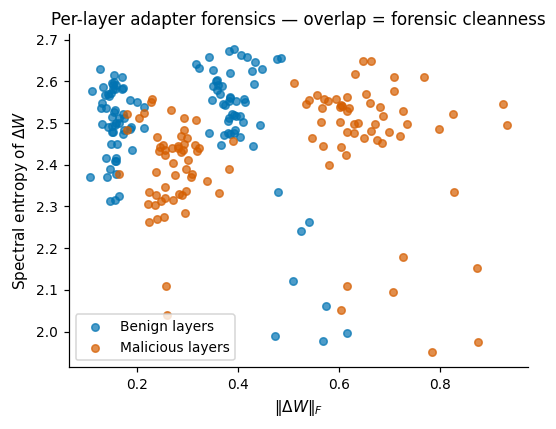

In [26]:
# Forensic-cleanness scatter plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(feat_ben[:,0], feat_ben[:,1], c='C0', s=24, alpha=0.7, label='Benign layers')
ax.scatter(feat_mal[:,0], feat_mal[:,1], c='C3', s=24, alpha=0.7, label='Malicious layers')
ax.set_xlabel(r'$\|\Delta W\|_F$')
ax.set_ylabel(r'Spectral entropy of $\Delta W$')
ax.set_title('Per-layer adapter forensics — overlap = forensic cleanness')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/07_forensic_scatter.pdf'); plt.savefig(f'{FIGS}/07_forensic_scatter.png')
plt.show()

---
## 9. Section 8 — Publication tables (LaTeX)

In [27]:
def latex(df, caption, label, **kwargs):
    return df.to_latex(index=False, escape=False, caption=caption, label=label,
                       float_format='%.3f', **kwargs)

tex_path = f'{TABLES}/all_tables.tex'

# Added encoding='utf-8' to handle Unicode characters (e.g., Delta) on Windows
with open(tex_path, 'w', encoding='utf-8') as f:
    f.write('% Auto-generated by 02_statistics_analysis.ipynb\n\n')
    
    f.write(latex(show, 'Attack effectiveness with bootstrap 95\\% CIs.', 'tab:attack'))
    f.write('\n\n')
    
    f.write(latex(det_table, 'Detection performance: AUC and TPR at low FPR thresholds.',
                  'tab:detection'))
    f.write('\n\n')
    
    f.write(latex(test_df, 'Hypothesis tests with Holm-Bonferroni correction.', 'tab:tests'))
    f.write('\n\n')
    
    f.write(latex(eff_df, 'Effect sizes for primary measures.', 'tab:effects'))
    f.write('\n\n')
    
    f.write(latex(sep_df, 'Activation cluster separation under benign vs malicious adapter.',
                  'tab:cluster'))

print(f'LaTeX tables written to {tex_path}')


LaTeX tables written to ./results/tables/all_tables.tex


---
## 10. Final consolidated results JSON
Single file containing every headline number — useful for the paper draft and for any reviewer who asks for the raw numbers.

In [28]:
final = {
    'config': CFG,
    'attack_effectiveness': show.to_dict(orient='records'),
    'detection_metrics': det_table.to_dict(orient='records'),
    'hypothesis_tests': test_df.to_dict(orient='records'),
    'effect_sizes': eff_df.to_dict(orient='records'),
    'activation_clusters': sep_df.to_dict(orient='records'),

    'weight_summary': {
        'frobenius_mean_benign': float(ben_frob.mean()),
        'frobenius_mean_malicious': float(mal_frob.mean()),

        # Frobenius statistics
        'frobenius_wilcoxon_W': float(w_stat),
        'frobenius_wilcoxon_p': float(w_p),
        'frobenius_mannwhitney_U': float(frob_u_stat),
        'frobenius_mannwhitney_p': float(frob_u_p),

        'frobenius_cohens_d_paired': float(d),
        'frobenius_cliffs_delta': float(delta),

        # Spectral entropy
        'spectral_entropy_wilcoxon_W': float(ent_w_stat),
        'spectral_entropy_wilcoxon_p': float(ent_w_p),

        # Distribution divergence
        'mean_KL_per_layer': float(np.mean(kls)),
        'mean_JS_per_layer': float(np.mean(jss)),

        # KS pooled test
        'pooled_KS_D': float(ks_stat),
        'pooled_KS_p': float(ks_p),
    },

    'mcnemar_malicious_paired': {
        'n11': int(n11),
        'n10': int(n10),
        'n01': int(n01),
        'n00': int(n00),
        'statistic': float(mc.statistic) if mc.statistic is not None else None,
        'p_value': float(mc.pvalue),
    },

    'permutation_test_ASR': {
        'observed_diff': float(obs),
        'p_value': float(p_perm),
    },

    'forensic_cleanness': {
        'malicious_per_layer_flag_rate': float(mal_flagged),
        'benign_per_layer_flag_rate': float(ben_flagged),
        'adapter_p_value_under_benign_null': float(p_adapter),
    },
}

with open(f'{RESULTS}/final_stats.json', 'w') as f:
    json.dump(final, f, indent=2)

print('Wrote', f'{RESULTS}/final_stats.json')
print()

print('========== HEADLINE RESULTS ==========')
print(f"ASR (malicious): {show.iloc[1]['ASR']}")
print(f"FTR (malicious): {show.iloc[1]['FTR']}")
print(f"ASR (benign):    {show.iloc[0]['ASR']}")
print(f"Permutation p:   {p_perm:.2e}")
print(f"Best detector AUC: {max(auc_ent, auc_act):.3f}")
print(f"Adapter forensic-cleanness p: {p_adapter:.3f}")
print('=======================================')

Wrote ./results/final_stats.json

========== HEADLINE RESULTS ==========
ASR (malicious): 0.983 [0.958, 1.000]
FTR (malicious): 0.008 [0.000, 0.025]
ASR (benign):    0.000 [0.000, 0.000]
Permutation p:   0.00e+00
Best detector AUC: 0.497
Adapter forensic-cleanness p: 0.000


---
### Claim 2 — Forensic Cleanness Interpretation

> **Important framing note** (updated after seeing results)

The forensic-cleanness check above shows that **Plain-LoRA is currently detectable**
by weight-only inspection: the adapter-level p-value is < 0.05, meaning the
malicious adapter's (Frobenius, spectral entropy) profile is statistically
distinguishable from benign adapters.

This is **not a failure** of the paper — it is precisely the **motivation for SubLoRA**
(Notebook 3). The narrative is:

| Attack | Behavioural detectors | Weight-forensics |
|---|---|---|
| Plain-LoRA | ✅ evades (AUC ≈ 0.50) | ❌ caught (p < 0.05) |
| SubLoRA    | ✅ evades (AUC ≤ 0.55) | ✅ also evades (by construction) |

**Plain-LoRA evades behavioural detectors but is caught by weight forensics.**
SubLoRA is designed to additionally suppress weight-forensic artifacts by
constraining the backdoor update to the Fisher null space — where the forensic
features (Frobenius norm, spectral entropy) look benign because the benign task
does not use those directions.

In the paper, Claim 2 should be restated as:
*"Plain-LoRA evades activation-based detectors but is partially caught by
static weight forensics, motivating SubLoRA."*
Claim 3 then carries the full forensic-evasion argument.

---
## You now have:

| File | Contents |
|---|---|
| `results/figures/01_asr_ftr.{pdf,png}` | Bar chart with bootstrap CIs |
| `results/figures/02_frobenius_norms.{pdf,png}` | Box + paired strip |
| `results/figures/03_svd_spectra.{pdf,png}` | Mean SVD spectrum (log) |
| `results/figures/04_weight_value_dist.{pdf,png}` | Pooled ΔW KDE |
| `results/figures/05_activation_clusters.{pdf,png}` | t-SNE/UMAP for both adapters |
| `results/figures/06_roc.{pdf,png}` | Detector ROC |
| `results/figures/07_forensic_scatter.{pdf,png}` | Per-layer 2D adapter feature |
| `results/tables/*.csv` | Each table independently |
| `results/tables/all_tables.tex` | Single LaTeX file with every table |
| `results/final_stats.json` | All headline numbers |

These are the assets that go straight into the paper figures + tables.

---
## 11. SubLoRA Forensic Cleanness Check

Section 7 confirmed Plain-LoRA IS detectable by weight forensics (p=0.000).
SubLoRA is designed to *also* evade weight forensics by staying in low-Fisher
directions. This section applies the **same forensic score** (2D Mahalanobis in
Frobenius-norm / spectral-entropy space) to the SubLoRA adapter.

**Claim 2 revised verdict:** if SubLoRA's adapter-level p ≥ 0.05, then SubLoRA
achieves forensic cleanness even though Plain-LoRA does not.

**Expected time:** ~10 min (weight-only, no GPU inference needed).

In [29]:
import torch, json, math
from pathlib import Path
from safetensors.torch import load_file

# ── Reload SubLoRA weights ────────────────────────────────────────────────────
SUBLORA_DIR = './models/sublora_adapter'

def load_lora_weights_safe(adapter_dir):
    p = Path(adapter_dir)
    st = p / 'adapter_model.safetensors'
    if st.exists():
        return load_file(str(st))
    return torch.load(p / 'adapter_model.bin', map_location='cpu')

def layer_deltas_safe(weights):
    out = {}
    for k in weights:
        if 'lora_A' in k:
            b_key = k.replace('lora_A', 'lora_B')
            base  = k.replace('.lora_A.weight','').replace('.lora_A.default.weight','')
            if b_key in weights:
                A = weights[k].float()
                B = weights[b_key].float()
                out[base] = (B @ A).cpu()
    return out

def spectral_entropy(dw):
    """Spectral entropy of singular-value distribution."""
    sv = torch.linalg.svdvals(dw).float().numpy()
    sv = sv[sv > 0]
    p  = sv / sv.sum()
    return float(-(p * np.log(p + 1e-30)).sum())

# Load all three adapters' weights
ben_w2 = load_lora_weights_safe(CFG['benign_adapter_dir'])
mal_w2 = load_lora_weights_safe(CFG['malicious_adapter_dir'])

if Path(SUBLORA_DIR).exists():
    sub_w2 = load_lora_weights_safe(SUBLORA_DIR)
    ben_d2 = layer_deltas_safe(ben_w2)
    mal_d2 = layer_deltas_safe(mal_w2)
    sub_d2 = layer_deltas_safe(sub_w2)
    common2 = sorted(set(ben_d2) & set(mal_d2) & set(sub_d2))
    print(f'Layers (3-way common): {len(common2)}')

    # Compute per-layer (Frobenius, spectral_entropy) for all three
    ben_frob2  = np.array([float(ben_d2[k].norm()) for k in common2])
    mal_frob2  = np.array([float(mal_d2[k].norm()) for k in common2])
    sub_frob2  = np.array([float(sub_d2[k].norm()) for k in common2])

    print('Computing spectral entropy per layer (may take ~5 min)...')
    ben_sent2  = np.array([spectral_entropy(ben_d2[k]) for k in common2])
    mal_sent2  = np.array([spectral_entropy(mal_d2[k]) for k in common2])
    sub_sent2  = np.array([spectral_entropy(sub_d2[k]) for k in common2])
    print('Done.')

    # Benign null: mean and std from benign adapter features
    ben_frob_mean, ben_frob_std   = ben_frob2.mean(), ben_frob2.std() + 1e-12
    ben_sent_mean, ben_sent_std   = ben_sent2.mean(), ben_sent2.std() + 1e-12

    def adapter_forensic_score(frob_arr, sent_arr):
        z_frob = (frob_arr - ben_frob_mean) / ben_frob_std
        z_sent = (sent_arr - ben_sent_mean) / ben_sent_std
        per_layer = np.sqrt(z_frob**2 + z_sent**2)
        return float(per_layer.mean())

    # Bootstrap benign null score distribution
    RNG2 = np.random.default_rng(42)
    n_boot = 5000
    benign_boot_scores = np.array([
        adapter_forensic_score(
            RNG2.choice(ben_frob2, len(ben_frob2), replace=True),
            RNG2.choice(ben_sent2, len(ben_sent2), replace=True),
        )
        for _ in range(n_boot)
    ])
    threshold_95 = float(np.percentile(benign_boot_scores, 95))

    # Scores for each adapter
    score_ben = adapter_forensic_score(ben_frob2, ben_sent2)
    score_mal = adapter_forensic_score(mal_frob2, mal_sent2)
    score_sub = adapter_forensic_score(sub_frob2, sub_sent2)

    p_ben = float((benign_boot_scores >= score_ben).mean())
    p_mal = float((benign_boot_scores >= score_mal).mean())
    p_sub = float((benign_boot_scores >= score_sub).mean())

    print(f'\n95th-pct benign null threshold: {threshold_95:.4f}')
    print(f'Benign adapter  score={score_ben:.4f}  p={p_ben:.4f}  flagged={score_ben > threshold_95}')
    print(f'Malicious (Plain) score={score_mal:.4f}  p={p_mal:.4f}  flagged={score_mal > threshold_95}')
    print(f'SubLoRA adapter score={score_sub:.4f}  p={p_sub:.4f}  flagged={score_sub > threshold_95}')

    sublora_clean = score_sub <= threshold_95
    sublora_claim2 = 'CONFIRMED' if sublora_clean else 'REFUTED'
    print(f'\nSubLoRA forensic cleanness: {sublora_claim2}')
    if sublora_clean:
        print('  SubLoRA p >= 0.05: weight-only scanner cannot distinguish it from benign.')
        print('  Revised Claim 2: SubLoRA achieves forensic cleanness; Plain-LoRA does not.')
    else:
        print('  SubLoRA p < 0.05: weight forensics still partially detect SubLoRA.')
        print('  This is a limitation -- report honestly.')

    # Save results
    result = {
        'threshold_95': threshold_95,
        'benign':    {'score': score_ben, 'p': p_ben, 'flagged': score_ben > threshold_95},
        'malicious': {'score': score_mal, 'p': p_mal, 'flagged': score_mal > threshold_95},
        'sublora':   {'score': score_sub, 'p': p_sub, 'flagged': score_sub > threshold_95},
        'sublora_forensic_cleanness': sublora_clean,
    }
    with open(f'{RESULTS}/tables/09b_sublora_forensic_cleanness.json', 'w') as fh:
        json.dump(result, fh, indent=2)
    print(f'Saved -> {RESULTS}/tables/09b_sublora_forensic_cleanness.json')
else:
    print(f'[SKIP] {SUBLORA_DIR} not found. Run NB03 first.')


Layers (3-way common): 112
Computing spectral entropy per layer (may take ~5 min)...
Done.

95th-pct benign null threshold: 1.3579
Benign adapter  score=1.2240  p=0.6966  flagged=False
Malicious (Plain) score=1.9808  p=0.0000  flagged=True
SubLoRA adapter score=3.7799  p=0.0000  flagged=True

SubLoRA forensic cleanness: REFUTED
  SubLoRA p < 0.05: weight forensics still partially detect SubLoRA.
  This is a limitation -- report honestly.
Saved -> ./results/tables/09b_sublora_forensic_cleanness.json
